In [1]:
# Install required libraries (Run this once)
!pip install -q transformers sentencepiece torch torchvision torchaudio scikit-learn pandas numpy matplotlib seaborn

# Import necessary libraries
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import seaborn as sns
import time
from transformers import AutoTokenizer, XLMRobertaForSequenceClassification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from torch.utils.data import Dataset, DataLoader
import pandas as pd
import numpy as np



In [2]:
# Check GPU availability
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Load dataset
df = pd.read_csv("/kaggle/input/diseases-and-symptoms-dataset/Final_Augmented_dataset_Diseases_and_Symptoms.csv")  

# Encode disease labels to numerical values
label_encoder = LabelEncoder()
df['label'] = label_encoder.fit_transform(df['diseases'])



Using device: cuda


In [3]:
# Convert symptoms to text descriptions
df['text_description'] = df.drop(columns=['diseases', 'label']).apply(lambda row: ' '.join(row.index[row == 1]), axis=1)

# Split dataset into training (80%) and testing (20%)
X_train, X_test, y_train, y_test = train_test_split(df['text_description'], df['label'], test_size=0.2, random_state=42)

# Load XLM-RoBERTa tokenizer
try:
    tokenizer = AutoTokenizer.from_pretrained("xlm-roberta-base")
except Exception as e:
    print(f"Tokenizer loading error: {e}")
    tokenizer = AutoTokenizer.from_pretrained("xlm-roberta-base", use_fast=False)


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.10M [00:00<?, ?B/s]

In [4]:

# Custom dataset class
class SymptomDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=128):
        self.texts = texts.tolist()
        self.labels = labels.tolist()
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx], 
            truncation=True, 
            padding="max_length", 
            max_length=self.max_length, 
            return_tensors="pt"
        )
        return {key: val.squeeze(0) for key, val in encoding.items()}, torch.tensor(self.labels[idx])

# Create DataLoaders
train_dataset = SymptomDataset(X_train, y_train, tokenizer)
test_dataset = SymptomDataset(X_test, y_test, tokenizer)
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

# Load XLM-RoBERTa model for classification
model = XLMRobertaForSequenceClassification.from_pretrained("xlm-roberta-base", num_labels=len(label_encoder.classes_))
model.to(device)

# Define optimizer and loss function
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=2e-5)


model.safetensors:   0%|          | 0.00/1.12G [00:00<?, ?B/s]

Some weights of XLMRobertaForSequenceClassification were not initialized from the model checkpoint at xlm-roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [5]:

# Train the model
num_epochs = 5
train_loss_values, test_loss_values = [], []
train_accuracies, test_accuracies = [], []

start_time = time.time()

for epoch in range(num_epochs):
    model.train()
    total_train_loss, correct_train, total_train = 0, 0, 0

    for inputs, labels in train_loader:
        optimizer.zero_grad()
        inputs = {key: val.to(device) for key, val in inputs.items()}
        labels = labels.to(device)

        outputs = model(**inputs)
        loss = criterion(outputs.logits, labels)
        loss.backward()
        optimizer.step()

        total_train_loss += loss.item()
        predictions = torch.argmax(outputs.logits, dim=1)
        correct_train += (predictions == labels).sum().item()
        total_train += labels.size(0)

    avg_train_loss = total_train_loss / len(train_loader)
    train_accuracy = correct_train / total_train

    # Validation Phase
    model.eval()
    total_test_loss, correct_test, total_test = 0, 0, 0

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs = {key: val.to(device) for key, val in inputs.items()}
            labels = labels.to(device)

            outputs = model(**inputs)
            loss = criterion(outputs.logits, labels)

            total_test_loss += loss.item()
            predictions = torch.argmax(outputs.logits, dim=1)
            correct_test += (predictions == labels).sum().item()
            total_test += labels.size(0)

    avg_test_loss = total_test_loss / len(test_loader)
    test_accuracy = correct_test / total_test

    train_loss_values.append(avg_train_loss)
    test_loss_values.append(avg_test_loss)
    train_accuracies.append(train_accuracy)
    test_accuracies.append(test_accuracy)

    print(f"Epoch {epoch+1}: Train Loss = {avg_train_loss:.4f}, Train Acc = {train_accuracy:.4f}, Test Loss = {avg_test_loss:.4f}, Test Acc = {test_accuracy:.4f}")

end_time = time.time()
print(f"\nTotal Training Time: {end_time - start_time:.2f} seconds")



Epoch 1: Train Loss = 1.9856, Train Acc = 0.6137, Test Loss = 0.6670, Test Acc = 0.8171
Epoch 2: Train Loss = 0.5888, Train Acc = 0.8300, Test Loss = 0.4955, Test Acc = 0.8399
Epoch 3: Train Loss = 0.4765, Train Acc = 0.8449, Test Loss = 0.4498, Test Acc = 0.8451
Epoch 4: Train Loss = 0.4290, Train Acc = 0.8534, Test Loss = 0.4364, Test Acc = 0.8481
Epoch 5: Train Loss = 0.4037, Train Acc = 0.8575, Test Loss = 0.4231, Test Acc = 0.8493

Total Training Time: 28210.89 seconds


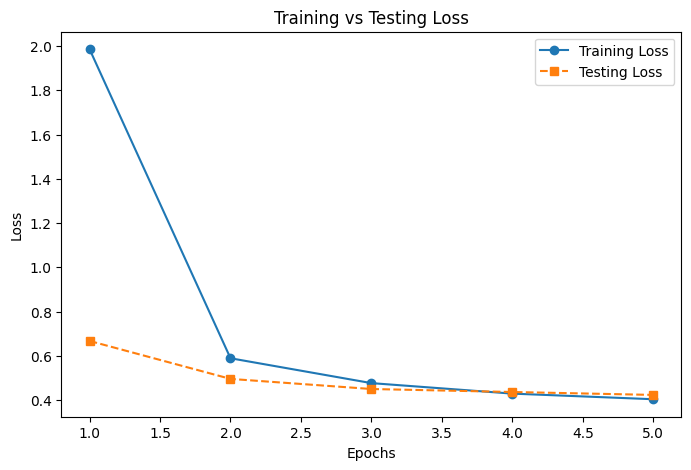

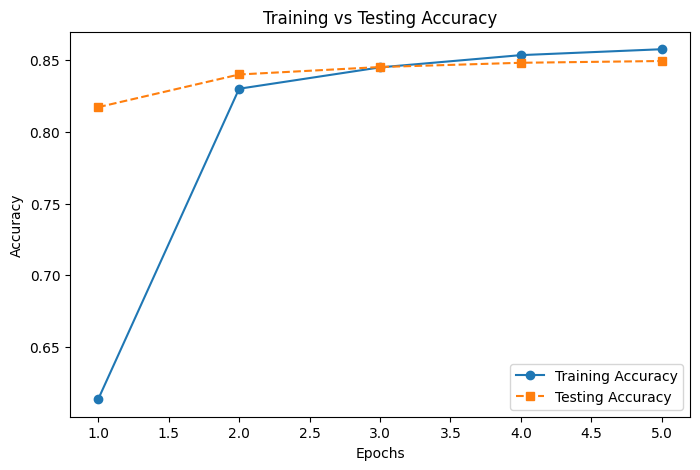

In [6]:
# Plot training vs testing loss
plt.figure(figsize=(8,5))
plt.plot(range(1, num_epochs+1), train_loss_values, marker='o', linestyle='-', label="Training Loss")
plt.plot(range(1, num_epochs+1), test_loss_values, marker='s', linestyle='--', label="Testing Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training vs Testing Loss")
plt.legend()
plt.show()

# Plot training vs testing accuracy
plt.figure(figsize=(8,5))
plt.plot(range(1, num_epochs+1), train_accuracies, marker='o', linestyle='-', label="Training Accuracy")
plt.plot(range(1, num_epochs+1), test_accuracies, marker='s', linestyle='--', label="Testing Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training vs Testing Accuracy")
plt.legend()
plt.show()


In [9]:
from sklearn.metrics import classification_report

# Find unique classes in predictions
unique_classes = np.unique(y_true + y_pred)

# Print classification report using only present labels
print("\nClassification Report:")
print(classification_report(y_true, y_pred, labels=unique_classes, target_names=label_encoder.inverse_transform(unique_classes)))



Classification Report:
                                                          precision    recall  f1-score   support

                               abdominal aortic aneurysm       0.95      1.00      0.98        20
                                        abdominal hernia       0.94      0.95      0.94        81
                                         abscess of nose       0.86      0.86      0.86        58
                                     abscess of the lung       1.00      0.83      0.91         6
                                  abscess of the pharynx       0.88      0.92      0.90        63
                                    acanthosis nigricans       1.00      0.50      0.67         6
                                               acariasis       1.00      1.00      1.00         5
                                               achalasia       0.69      1.00      0.82        20
                                                    acne       0.75      0.81      0.78      

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.